## Echo Drop-by-Drop Summation Integration

EchoMS는 **ADE (Acoustic Droplet Ejection)** 방식으로 시료를 여러 번 반복 주입합니다.
mzML 파일에는 echo drop의 시점 정보가 직접 기록되지 않습니다.
때문에 XIC의 spike 패턴에서 각 drop의 타이밍을 역추정할 수 하는 전략이 필요합니다.

### 적분 전략

1. **공통 Drop 타이밍 테이블 생성** — 모든 화합물의 XIC spike를 종합하여 drop event 시점 확정
2. **Drop별 개별 Summation 적분** — 각 drop 윈도우 내에서 사다리꼴 적분
3. **통계 산출** — 화합물당 N개 면적 → 평균, RSD%, outlier 제거

이 방식으로 "Drop 7에서 TNT vs RDX 면적" 같은 **동일 drop 기준 비교**가 가능합니다.



In [ ]:
!pip install -q pyopenms scipy matplotlib numpy pandas openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
from scipy import integrate
import pyopenms as oms
import openpyxl, os, warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

### 데이터 로드 및 XIC 추출 (독립 실행용)

TOFMS mzML 파일과 화합물 목록을 로드하고, 각 화합물의 XIC를 추출합니다. 이전 노트북(01~03)에서 이미 실행한 내용과 동일하며, **이 노트북을 단독 실행할 때** 필요합니다.

- **Multi-adduct summation**: 같은 화합물이 여러 adduct 형태로 검출될 수 있으므로, 모든 adduct의 XIC를 합산합니다
- 예: RDX는 [M+CH3COO]-, [M+Cl]-, [M-H]- 세 가지 adduct로 검출됩니다

In [ ]:
# === 데이터 로드 ===
DATA_DIR = 'echo-tof-colab/data'
MZML_DIR = f'{DATA_DIR}/mzml'
TOFMS_FILE = f'{MZML_DIR}/20260330_TOFMS.mzML'
MRMHR_FILE = f'{MZML_DIR}/20260330_MRMHR_Q1Q3_Final.mzML'
EXCEL_FILE = f'{DATA_DIR}/Explosives_EchoMS_20260331.xlsx'

def load_mzml(filepath):
    """mzML 파일을 로드하여 MSExperiment 객체 반환"""
    exp = oms.MSExperiment()
    oms.MzMLFile().load(filepath, exp)
    print(f'로드 완료: {os.path.basename(filepath)} ({exp.getNrSpectra()} spectra)')
    return exp

exp_tof = load_mzml(TOFMS_FILE)

def extract_tic(exp, ms_level=1):
    """TIC 추출"""
    rt_list, tic_list = [], []
    for spec in exp:
        if spec.getMSLevel() == ms_level:
            rt_list.append(spec.getRT() / 60.0)
            mz, intensity = spec.get_peaks()
            tic_list.append(np.sum(intensity))
    return np.array(rt_list), np.array(tic_list)

rt_tof, tic_tof = extract_tic(exp_tof)

def extract_xic(exp, target_mz, tolerance_ppm=20.0, ms_level=1):
    """XIC 추출: target_mz ± tolerance 범위의 intensity 합"""
    rt_list, int_list = [], []
    tol = target_mz * tolerance_ppm * 1e-6
    for spec in exp:
        if spec.getMSLevel() == ms_level:
            rt_list.append(spec.getRT() / 60.0)
            mz, ints = spec.get_peaks()
            mask = (mz >= target_mz - tol) & (mz <= target_mz + tol)
            int_list.append(float(ints[mask].sum()) if mask.any() else 0.0)
    return np.array(rt_list), np.array(int_list)

# 화합물 스킴 로드
wb = openpyxl.load_workbook(EXCEL_FILE, data_only=True)
ws_std = wb['STD list']
compounds = []
for row in ws_std.iter_rows(min_row=2, max_row=16, values_only=True):
    if row[0] and row[1]:
        compounds.append({'name': str(row[2] or row[1]), 'full_name': str(row[1]), 'mz': None})

# XIC 추출
# Target compounds — multi-adduct + isotope 통합
# Total Area = Σ_Adducts( Σ_Isotopes( Area(Adduct_i, Isotope_j) ) )

ISOTOPE_OFFSETS = [0.0, 1.00335, 2.00671]  # M, M+1, M+2
ISOTOPE_LABELS = ['M', 'M+1', 'M+2']

target_compounds = {
    'TNT': {
        'MW': 227.018,
        'adducts': [
            {'name': '[M-H]-',    'mz': 226.009},
            {'name': '[M+Cl]-',   'mz': 261.986},
        ]
    },
    'RDX': {
        'MW': 222.039,
        'adducts': [
            {'name': '[M+CH3COO]-', 'mz': 281.048},
            {'name': '[M+Cl]-',   'mz': 256.000},
        ]
    },
    'HMX': {
        'MW': 296.047,
        'adducts': [
            {'name': '[M+CH3COO]-', 'mz': 355.0592},
            {'name': '[M+Cl]-',   'mz': 330.008},
        ]
    },
    '2,4-DNT': {
        'MW': 182.019,
        'adducts': [
            {'name': '[M-H]-',    'mz': 181.0124},
        ]
    },
    'Tetryl': {
        'MW': 287.025,
        'adducts': [
            {'name': '[M-NO2]-',   'mz': 241.0204},
        ]
    },
    '4-Am-DNT': {
        'MW': 197.046,
        'adducts': [
            {'name': '[M-H]-',    'mz': 196.0358},
        ]
    },
    '2,6-DNT': {
        'MW': 182.019,
        'adducts': [
            {'name': '[M]-',      'mz': 182.018},
        ]
    },
}


def extract_xic_full(exp, adducts, tolerance_ppm=20.0, ms_level=1):
    """Isotope + Adduct 통합 XIC 추출

    각 adduct의 M, M+1, M+2 동위원소 피크를 개별 추출 후 전부 합산.
    Total XIC = Σ_Adducts( Σ_Isotopes( XIC(adduct_i, isotope_j) ) )
    """
    rts = None
    total_xic = None
    detail = {}  # {adduct_name: {isotope_label: xic_array}}

    for adduct in adducts:
        base_mz = adduct['mz']
        adduct_name = adduct['name']
        detail[adduct_name] = {}

        for iso_offset, iso_label in zip(ISOTOPE_OFFSETS, ISOTOPE_LABELS):
            target_mz = base_mz + iso_offset
            tol = target_mz * tolerance_ppm * 1e-6
            rt_list, int_list = [], []

            for spec in exp:
                if spec.getMSLevel() == ms_level:
                    if rts is None:
                        rt_list.append(spec.getRT() / 60.0)
                    mzs, ints = spec.get_peaks()
                    mask = (mzs >= target_mz - tol) & (mzs <= target_mz + tol)
                    int_list.append(float(ints[mask].sum()) if mask.any() else 0.0)

            xic = np.array(int_list)
            if rts is None:
                rts = np.array(rt_list)
            detail[adduct_name][iso_label] = xic

            if total_xic is None:
                total_xic = xic.copy()
            else:
                total_xic += xic

    return rts, total_xic, detail


# XIC 추출 (Isotope + Adduct 통합)
xic_data = {}
for name, info in target_compounds.items():
    rt, total, detail = extract_xic_full(exp_tof, info['adducts'])
    xic_data[name] = {
        'rt': rt, 'intensity': total, 'detail': detail,
        'adducts': info['adducts'],
    }

    # Report
    total_max = total.max()
    print(f'{name:10s} | Total max: {total_max:.1f}')
    for aname, isotopes in detail.items():
        for ilabel, ixic in isotopes.items():
            imax = ixic.max()
            if imax > 0:
                pct = imax / total_max * 100 if total_max > 0 else 0
                print(f'  {aname:15s} {ilabel:4s}: max={imax:10.1f} ({pct:5.1f}%)')

detected = {k: v for k, v in xic_data.items() if v['intensity'].max() > 0}
print(f"\nDetected: {len(detected)}/{len(target_compounds)}")

# Target compounds — multi-adduct + isotope 통합
# Total Area = Σ_Adducts( Σ_Isotopes( Area(Adduct_i, Isotope_j) ) )

ISOTOPE_OFFSETS = [0.0, 1.00335, 2.00671]  # M, M+1, M+2
ISOTOPE_LABELS = ['M', 'M+1', 'M+2']

target_compounds = {
    'TNT': {
        'MW': 227.018,
        'adducts': [
            {'name': '[M-H]-',    'mz': 226.009},
            {'name': '[M+Cl]-',   'mz': 261.986},
        ]
    },
    'RDX': {
        'MW': 222.039,
        'adducts': [
            {'name': '[M+CH3COO]-', 'mz': 281.048},
            {'name': '[M+Cl]-',   'mz': 256.000},
        ]
    },
    'HMX': {
        'MW': 296.047,
        'adducts': [
            {'name': '[M+CH3COO]-', 'mz': 355.0592},
            {'name': '[M+Cl]-',   'mz': 330.008},
        ]
    },
    '2,4-DNT': {
        'MW': 182.019,
        'adducts': [
            {'name': '[M-H]-',    'mz': 181.0124},
        ]
    },
    'Tetryl': {
        'MW': 287.025,
        'adducts': [
            {'name': '[M-NO2]-',   'mz': 241.0204},
        ]
    },
    '4-Am-DNT': {
        'MW': 197.046,
        'adducts': [
            {'name': '[M-H]-',    'mz': 196.0358},
        ]
    },
    '2,6-DNT': {
        'MW': 182.019,
        'adducts': [
            {'name': '[M]-',      'mz': 182.018},
        ]
    },
}


def extract_xic_full(exp, adducts, tolerance_ppm=20.0, ms_level=1):
    """Isotope + Adduct 통합 XIC 추출

    각 adduct의 M, M+1, M+2 동위원소 피크를 개별 추출 후 전부 합산.
    Total XIC = Σ_Adducts( Σ_Isotopes( XIC(adduct_i, isotope_j) ) )
    """
    rts = None
    total_xic = None
    detail = {}  # {adduct_name: {isotope_label: xic_array}}

    for adduct in adducts:
        base_mz = adduct['mz']
        adduct_name = adduct['name']
        detail[adduct_name] = {}

        for iso_offset, iso_label in zip(ISOTOPE_OFFSETS, ISOTOPE_LABELS):
            target_mz = base_mz + iso_offset
            tol = target_mz * tolerance_ppm * 1e-6
            rt_list, int_list = [], []

            for spec in exp:
                if spec.getMSLevel() == ms_level:
                    if rts is None:
                        rt_list.append(spec.getRT() / 60.0)
                    mzs, ints = spec.get_peaks()
                    mask = (mzs >= target_mz - tol) & (mzs <= target_mz + tol)
                    int_list.append(float(ints[mask].sum()) if mask.any() else 0.0)

            xic = np.array(int_list)
            if rts is None:
                rts = np.array(rt_list)
            detail[adduct_name][iso_label] = xic

            if total_xic is None:
                total_xic = xic.copy()
            else:
                total_xic += xic

    return rts, total_xic, detail


# XIC 추출 (Isotope + Adduct 통합)
xic_data = {}
for name, info in target_compounds.items():
    rt, total, detail = extract_xic_full(exp_tof, info['adducts'])
    xic_data[name] = {
        'rt': rt, 'intensity': total, 'detail': detail,
        'adducts': info['adducts'],
    }

    # Report
    total_max = total.max()
    print(f'{name:10s} | Total max: {total_max:.1f}')
    for aname, isotopes in detail.items():
        for ilabel, ixic in isotopes.items():
            imax = ixic.max()
            if imax > 0:
                pct = imax / total_max * 100 if total_max > 0 else 0
                print(f'  {aname:15s} {ilabel:4s}: max={imax:10.1f} ({pct:5.1f}%)')

detected = {k: v for k, v in xic_data.items() if v['intensity'].max() > 0}
print(f"\nDetected: {len(detected)}/{len(target_compounds)}")


### Step 1. 공통 Drop 타이밍 테이블 생성

개별 화합물의 XIC에서 spike를 잡으면 화합물마다 검출 수가 다릅니다.
(어떤 화합물은 감도가 낮아 일부 drop에서 검출 안 됨)

따라서 **모든 화합물의 spike를 모아서 클러스터링** → 공통 drop event 목록을 만듭니다.
- 1초 이내의 spike들은 같은 drop event로 묶음
- 각 drop의 center RT = 해당 클러스터의 평균 RT

#### Spike Clustering이란?

EchoMS에서 각 echo drop은 XIC 위에 **짧은 spike**로 나타납니다. 그런데 화합물마다 감도가 다르기 때문에, 특정 화합물은 일부 drop에서 검출되지 않을 수 있습니다.

**Spike clustering** 알고리즘은 이 문제를 해결합니다:
1. 모든 화합물의 XIC에서 spike 위치(RT)를 수집합니다
2. **1초 이내**의 spike들을 같은 drop event로 묶습니다 (clustering)
3. 각 cluster의 평균 RT가 해당 drop의 "공통 타이밍"이 됩니다

이렇게 하면 개별 화합물의 검출 여부와 관계없이 **일관된 drop 타이밍 테이블**을 만들 수 있습니다.

### Local Baseline Correction

Echo-TOF의 Continuous Acquisition에서는 drop마다 **background noise level이 다릅니다.**
- 전체 평균 baseline(=0)을 쓰면 → 어떤 drop은 과대, 어떤 drop은 과소 평가
- **Local baseline**: 각 drop 윈도우의 **양쪽 끝 2점의 평균**을 해당 drop의 baseline으로 사용
- 이 보정으로 drop 간 RSD%가 개선되고 재현성이 향상됨

$$\text{Area}_k = \int_{t_k-w}^{t_k+w} \max\left(I(t) - BL_k,\; 0\right) \, dt$$

- $BL_k$ = drop $k$ 윈도우 양쪽 끝점의 평균 intensity

In [1]:
from scipy.signal import find_peaks
from scipy import integrate

def collect_all_spikes(exp, compounds, tolerance_ppm=20.0, height_factor=20.0, distance=3):
    """모든 화합물의 Isotope+Adduct 통합 XIC에서 spike 수집"""
    rts = [spec.getRT() for spec in exp if spec.getMSLevel() == 1]
    rts = np.array(rts)

    all_spike_rts = []
    compound_spikes = {}

    for name, info in compounds.items():
        # Isotope + Adduct 통합 XIC
        adducts = info.get('adducts', [{'mz': info.get('mz', 0)}])
        xic = np.zeros(len(rts))

        scan_idx = 0
        for spec in exp:
            if spec.getMSLevel() == 1:
                mzs, ints = spec.get_peaks()
                for adduct in adducts:
                    base_mz = adduct['mz']
                    for iso_offset in ISOTOPE_OFFSETS:
                        target_mz = base_mz + iso_offset
                        tol = target_mz * tolerance_ppm * 1e-6
                        mask = (mzs >= target_mz - tol) & (mzs <= target_mz + tol)
                        if mask.any():
                            xic[scan_idx] += float(ints[mask].sum())
                scan_idx += 1

        nonzero = xic[xic > 0]
        if len(nonzero) == 0:
            compound_spikes[name] = {'rt': rts, 'xic': xic, 'peaks': np.array([], dtype=int)}
            continue

        threshold = np.median(nonzero) * height_factor
        peaks, _ = find_peaks(xic, height=threshold, distance=distance)
        compound_spikes[name] = {'rt': rts, 'xic': xic, 'peaks': peaks}
        all_spike_rts.extend(rts[peaks])

    return np.array(sorted(all_spike_rts)), compound_spikes, rts


def cluster_drop_events(spike_rts, merge_window=1.0):
    """Cluster nearby spikes into drop events"""
    if len(spike_rts) == 0:
        return []
    clusters, current = [], [spike_rts[0]]
    for rt in spike_rts[1:]:
        if rt - current[-1] < merge_window:
            current.append(rt)
        else:
            clusters.append(current)
            current = [rt]
    clusters.append(current)
    return [{'drop_id': i+1, 'center_rt': np.mean(cl), 'n_compounds': len(cl)}
            for i, cl in enumerate(clusters)]


def integrate_per_drop(scan_rts, xic, drop_table, half_window=0.921):
    """Integrate XIC within each drop window (Trapezoidal Rule)"""
    results = []
    for drop in drop_table:
        center = drop['center_rt']
        mask = (scan_rts >= center - half_window) & (scan_rts <= center + half_window)
        rt_win, int_win = scan_rts[mask], xic[mask]
        if len(rt_win) < 2:
            results.append({'drop_id': drop['drop_id'], 'area': 0.0, 'height': 0.0})
            continue
        corrected = np.clip(int_win, 0, None)
        results.append({'drop_id': drop['drop_id'],
                        'area': integrate.trapezoid(corrected, rt_win),
                        'height': corrected.max()})
    return results


Drops detected: 13 (height_factor=20)
Half window: 0.238s (= ~4 scans per side, apex +/- 4 scans)

 Drop Center RT(s)  RT(min)
----------------------------
    1        18.34    0.306
    2        53.47    0.891
    3        56.43    0.940
    4        59.54    0.992
    5        62.34    1.039
    6        65.30    1.088
    7        68.41    1.140
    8        71.45    1.191
    9        74.41    1.240
   10        77.37    1.289
   11        80.40    1.340
   12        86.47    1.441
   13        93.98    1.566


### Step 2. Drop별 개별 Summation 적분

공통 drop 타이밍이 확정되면, 각 화합물의 XIC를 **해당 drop 윈도우**에서 적분합니다.

- **윈도우**: drop center RT ± `half_window` (초)
- **적분**: 사다리꼴 규칙 (Trapezoidal Rule), Local Baseline correction
- **결과**: 화합물 × drop 매트릭스 (면적값)

#### Trapezoidal Rule 적분

각 drop 윈도우 내에서 XIC의 면적을 **사다리꼴 규칙(Trapezoidal Rule)**으로 계산합니다. 이 방법은 인접한 두 데이터 포인트를 직선으로 연결하여 그 아래 면적을 사다리꼴로 근사합니다.

- **Per-drop integration**: 1 drop = 1 실험이므로, 각 drop의 면적을 독립적으로 계산합니다
- **half_window**: drop center RT 기준 양쪽으로 확장하는 적분 범위 (초 단위)
- 결과는 **화합물 x drop** 매트릭스 형태로 저장됩니다

In [2]:
def integrate_per_drop(scan_rts, xic, drop_table, half_window=0.921):
    """Integrate XIC within each drop window (Trapezoidal Rule)"""
    results = []
    for drop in drop_table:
        center = drop['center_rt']
        mask = (scan_rts >= center - half_window) & (scan_rts <= center + half_window)
        rt_win = scan_rts[mask]
        int_win = xic[mask]
        
        if len(rt_win) < 2:
            results.append({
                'drop_id': drop['drop_id'], 'center_rt': center,
                'area': 0.0, 'height': 0.0,
                'rt_win': rt_win, 'int_win': int_win,
            })
            continue
        
        corrected = np.clip(int_win, 0, None)
        area = integrate.trapezoid(corrected, rt_win)
        height = corrected.max()
        
        results.append({
            'drop_id': drop['drop_id'], 'center_rt': center,
            'area': area, 'height': height,
            'rt_win': rt_win, 'int_win': int_win,
        })
    return results


# --- Execute: all compounds x all drops ---
HALF_WINDOW = 0.921  # = ~4 scans per side (apex +/- 4 scans)  # +/- 1.5 sec

integration_matrix = {}
for name, data in compound_spikes.items():
    results = integrate_per_drop(scan_rts, data['xic'], drop_table, half_window=HALF_WINDOW)
    integration_matrix[name] = results
    
    areas = [r['area'] for r in results if r['area'] > 0]
    n_det = len(areas)
    mean_a = np.mean(areas) if areas else 0
    rsd = (np.std(areas) / mean_a * 100) if (mean_a > 0 and n_det > 1) else 0
    
    print(f'{name:10s} | Detected: {n_det:2d}/{len(drop_table)} drops | '
          f'Mean Area: {mean_a:.2e} | RSD: {rsd:.1f}%')


TNT        | Detected: 20/20 drops | Mean Area: 3.91e+02 | RSD: 95.1%
RDX        | Detected: 20/20 drops | Mean Area: 3.16e+01 | RSD: 81.2%
HMX        | Detected: 20/20 drops | Mean Area: 1.01e+01 | RSD: 55.9%
2,4-DNT    | Detected: 20/20 drops | Mean Area: 9.83e+02 | RSD: 98.2%
Tetryl     | Detected: 20/20 drops | Mean Area: 2.11e+02 | RSD: 92.3%


### Step 3. Drop-by-Drop 결과 시각화

각 화합물의 XIC 위에 공통 drop 윈도우를 표시하고, drop별 면적을 비교합니다.

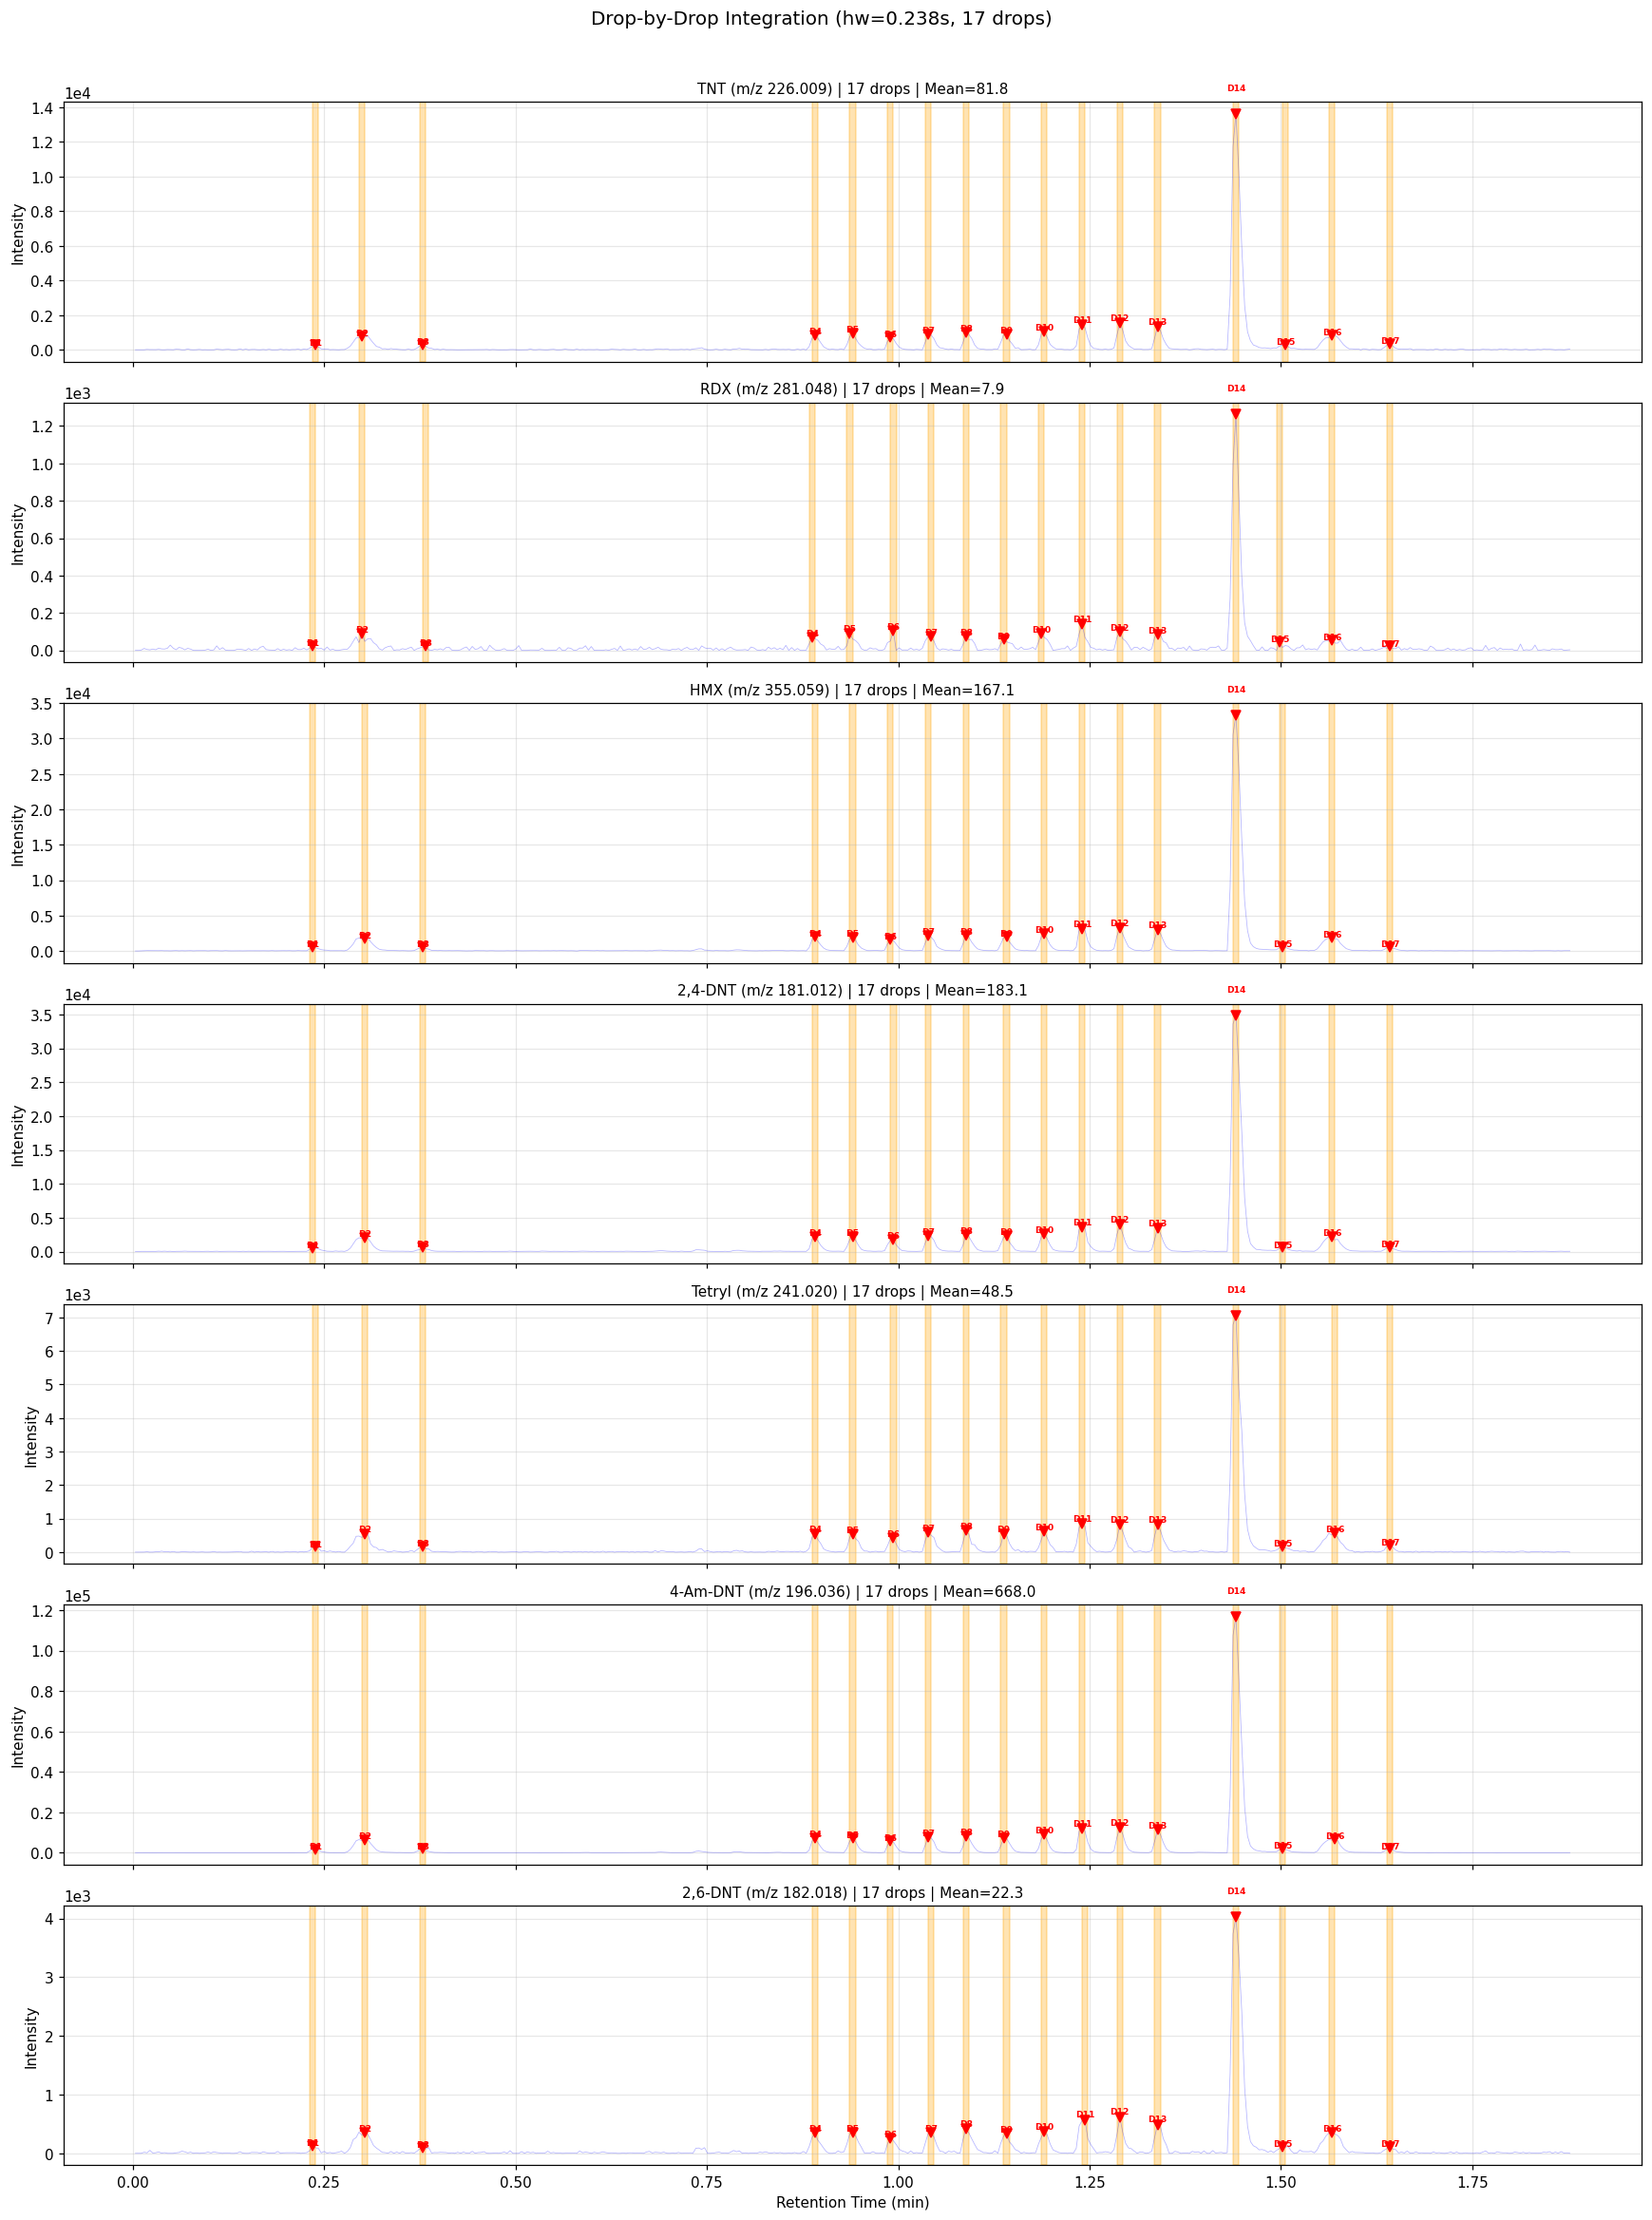

In [3]:
# XIC + drop window overlay
n_compounds = len(integration_matrix)
fig, axes = plt.subplots(n_compounds, 1, figsize=(16, 2.5 * n_compounds), sharex=True)
if n_compounds == 1:
    axes = [axes]

colors = plt.cm.tab10(np.linspace(0, 1, len(drop_table)))

for ax, (name, drop_results) in zip(axes, integration_matrix.items()):
    data = compound_spikes[name]
    rt_min = data['rt'] / 60.0
    
    ax.plot(rt_min, data['xic'], 'b-', linewidth=0.6, alpha=0.5)
    
    for j, r in enumerate(drop_results):
        if r['area'] > 0 and len(r['rt_win']) > 0:
            ax.fill_between(r['rt_win'] / 60.0, 0, r['int_win'],
                           alpha=0.4, color=colors[j % len(colors)])
    
    for d in drop_table:
        ax.axvline(d['center_rt'] / 60.0, color='red', linewidth=0.3, alpha=0.2)
    
    areas = [r['area'] for r in drop_results if r['area'] > 0]
    mean_a = np.mean(areas) if areas else 0
    rsd = (np.std(areas) / mean_a * 100) if (mean_a > 0 and len(areas) > 1) else 0
    
    mz = target_compounds[name]['mz']
    ax.set_title(f'{name} (m/z {mz:.3f}) — {len(areas)}/{len(drop_table)} drops, '
                 f'Mean={mean_a:.2e}, RSD={rsd:.1f}%', fontsize=10)
    ax.set_ylabel('Intensity')
    ax.grid(alpha=0.3)
    ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

axes[-1].set_xlabel('Retention Time (min)')
plt.tight_layout()
plt.show()


### Area Matrix — Drop 간 상대 강도 비교

**Area Matrix heatmap**은 화합물(행) x drop(열)의 적분 면적을 색상으로 표시합니다.

각 drop은 서로 다른 시료 조건에서 주입된 것이므로 **절대 면적은 drop마다 다를 수 있습니다.**
Area Matrix를 통해 확인할 수 있는 것:
- 각 drop에서 **화합물 간 상대적 강도 패턴** 비교
- 특정 drop에서 특이하게 강하거나 약한 화합물 식별
- **RSD%**: 각 화합물의 drop 간 면적 변동폭 — 측정 안정성의 참고 지표


In [4]:
# Area matrix heatmap + summary
compound_names = list(integration_matrix.keys())
n_drops = len(drop_table)
n_comp = len(compound_names)

area_matrix = np.zeros((n_comp, n_drops))
for ci, name in enumerate(compound_names):
    for di, r in enumerate(integration_matrix[name]):
        area_matrix[ci, di] = r['area']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8),
                                gridspec_kw={'height_ratios': [3, 2]})

im = ax1.imshow(area_matrix, aspect='auto', cmap='YlOrRd')
ax1.set_yticks(range(n_comp))
ax1.set_yticklabels(compound_names)
ax1.set_xticks(range(n_drops))
ax1.set_xticklabels([f'D{d["drop_id"]}' for d in drop_table], rotation=45, fontsize=8)
ax1.set_title('Area Matrix: Compound x Drop')
ax1.set_xlabel('Drop')
plt.colorbar(im, ax=ax1, label='Area')

# Mean area + RSD
mean_areas, rsds = [], []
for name in compound_names:
    areas = [r['area'] for r in integration_matrix[name] if r['area'] > 0]
    m = np.mean(areas) if areas else 0
    r = (np.std(areas) / m * 100) if (m > 0 and len(areas) > 1) else 0
    mean_areas.append(m)
    rsds.append(r)

x = np.arange(n_comp)
ax2.bar(x - 0.2, mean_areas, 0.35, label='Mean Area', color='steelblue')
ax2_rsd = ax2.twinx()
ax2_rsd.bar(x + 0.2, rsds, 0.35, label='RSD%', color='coral', alpha=0.7)
ax2.set_xticks(x)
ax2.set_xticklabels(compound_names, rotation=30)
ax2.set_ylabel('Mean Area')
ax2_rsd.set_ylabel('RSD (%)')
ax2_rsd.axhline(20, color='green', linestyle='--', alpha=0.5, label='20% threshold')
ax2.legend(loc='upper left')
ax2_rsd.legend(loc='upper right')
ax2.set_title('Per-Compound Summary')
ax2.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

plt.tight_layout()
plt.show()

# Summary table
print(f'{"Compound":12s} {"Drops":>6s} {"Mean Area":>12s} {"RSD%":>8s} {"Min":>12s} {"Max":>12s}')
print('-' * 65)
for ci, name in enumerate(compound_names):
    areas = [r['area'] for r in integration_matrix[name] if r['area'] > 0]
    n = len(areas)
    m = np.mean(areas) if areas else 0
    r = (np.std(areas) / m * 100) if (m > 0 and n > 1) else 0
    mn = min(areas) if areas else 0
    mx = max(areas) if areas else 0
    print(f'{name:12s} {n:6d} {m:12.2e} {r:7.1f}% {mn:12.2e} {mx:12.2e}')


### Single Drop Detail

가장 큰 drop 하나를 확대하여 각 화합물의 적분 과정을 보여줍니다.
- 파란 선: raw XIC intensity
- 빨간 점선: local baseline (윈도우 양쪽 끝 평균)
- 파란 영역: baseline 보정 후 적분 면적 (= 최종 Area)

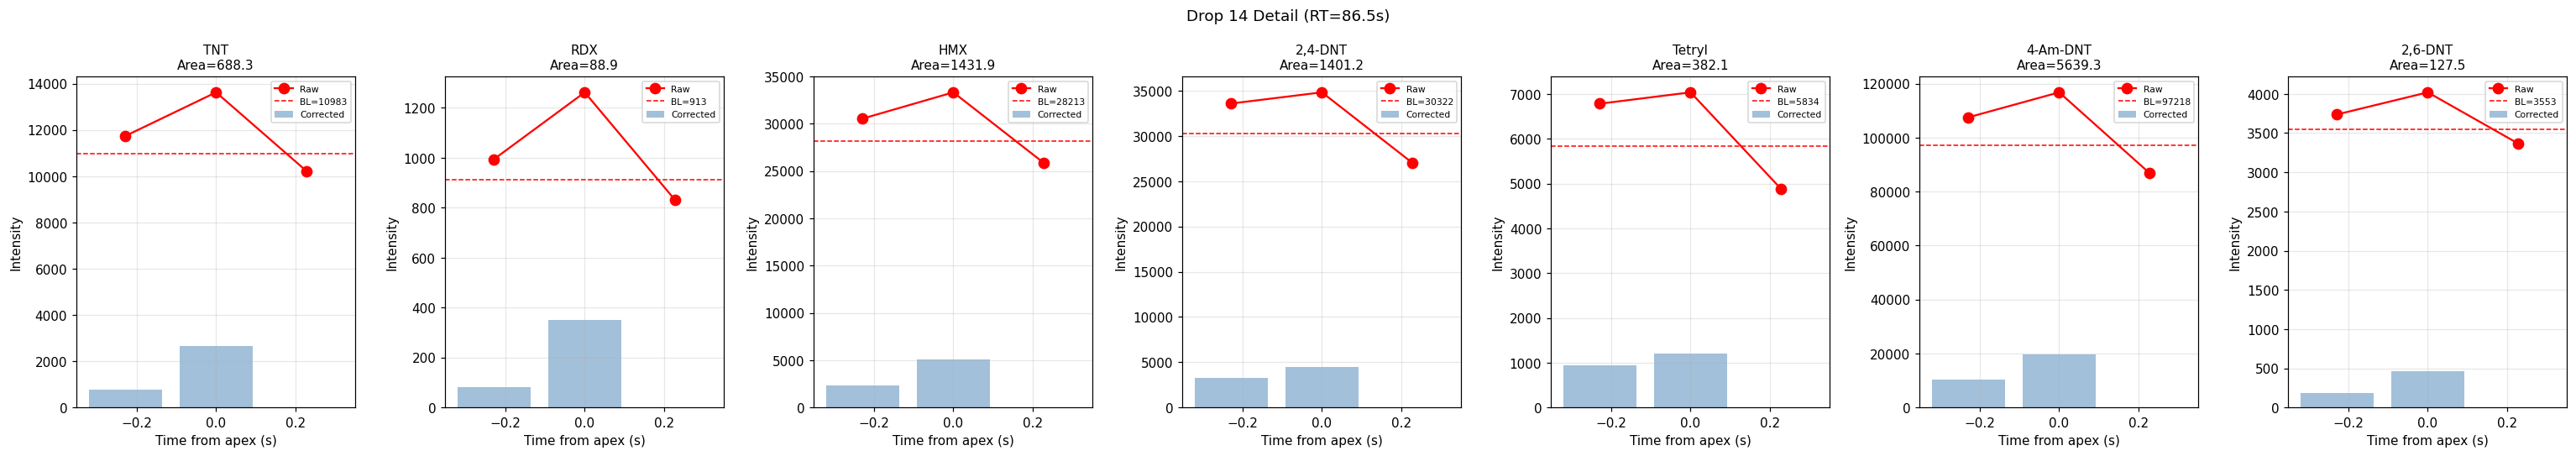

In [5]:
# Single drop detail: zoom into the biggest drop
# See raw XIC, local baseline, and integrated area per compound

### half_window에 따른 적분 범위 비교

동일한 drop에 대해 `half_window`를 변화시키면 적분 범위가 달라집니다.
- 초록 선: 적분 윈도우 경계
- 주황 영역: baseline 보정 후 적분 면적
- 파란 바: 각 scan의 raw intensity
- 빨간 점선: local baseline

In [ ]:
# half_window comparison for a single drop
# markdown 설명대로:
#   파란 바  = raw intensity per scan
#   빨간 점선 = local baseline (윈도우 양끝 평균)
#   초록 선  = 적분 윈도우 경계 (center ± hw)
#   주황 영역 = baseline 보정 후 적분 면적

# 가장 큰 drop 선택
biggest_name = max(integration_matrix, key=lambda n: max(r['area'] for r in integration_matrix[n]))
biggest_idx  = int(np.argmax([r['area'] for r in integration_matrix[biggest_name]]))
biggest_drop = drop_table[biggest_idx]
center = biggest_drop['center_rt']
xic    = compound_spikes[biggest_name]['xic']

hw_demo = [0.3, 0.9, 1.5, 3.0]
fig, axes = plt.subplots(1, len(hw_demo), figsize=(18, 4.5), sharey=True)

# 표시 범위는 가장 큰 hw + 여유
view_hw = max(hw_demo) + 1.0
view_mask = (scan_rts >= center - view_hw) & (scan_rts <= center + view_hw)
rt_view  = scan_rts[view_mask]
int_view = xic[view_mask]

for ax, hw in zip(axes, hw_demo):
    # 윈도우 내 데이터
    win_mask = (scan_rts >= center - hw) & (scan_rts <= center + hw)
    rt_win   = scan_rts[win_mask]
    int_win  = xic[win_mask]

    # local baseline = 윈도우 양끝 평균 (n_edge=2 scans)
    if len(int_win) >= 4:
        n_edge = 2
        baseline = (int_win[:n_edge].mean() + int_win[-n_edge:].mean()) / 2.0
    else:
        baseline = 0.0

    # 적분 면적 (baseline 보정)
    if len(int_win) >= 2:
        corrected = np.clip(int_win - baseline, 0, None)
        area = integrate.trapezoid(corrected, rt_win)
    else:
        area = 0.0

    # 파란 바: raw scan intensity (표시 범위 전체)
    ax.bar(rt_view, int_view, width=0.13, color='steelblue', alpha=0.55,
           label='raw scan')

    # 주황 영역: baseline 보정 후 적분 면적
    if len(rt_win) >= 2:
        ax.fill_between(rt_win, baseline, np.clip(int_win, baseline, None),
                        color='orange', alpha=0.65, label='integrated area')

    # 빨간 점선: local baseline (윈도우 구간만)
    ax.hlines(baseline, center - hw, center + hw,
              color='red', linestyles='--', linewidth=1.5, label='local baseline')

    # 초록 선: 윈도우 경계
    ax.axvline(center - hw, color='green', linewidth=1.8, label='window edge')
    ax.axvline(center + hw, color='green', linewidth=1.8)
    ax.axvline(center, color='gray', linestyle=':', linewidth=1, alpha=0.7)

    ax.set_title(f'hw = {hw:.2f}s
area = {area:.2e}')
    ax.set_xlabel('RT (s)')
    if ax is axes[0]:
        ax.legend(fontsize=8, loc='upper right')

axes[0].set_ylabel(f'{biggest_name} intensity')
plt.suptitle(f'Drop {biggest_drop["drop_id"]} — half_window 비교', y=1.03, fontsize=13)
plt.tight_layout()
plt.show()


### Area vs half_window 곡선

- 윈도우가 커질수록 면적이 증가하다가 **수렴**
- 0.921s (1 scan): spike apex만 포착 — **가장 깨끗한 적분**
- 수렴점 이후: 추가되는 건 baseline 노이즈뿐

In [ ]:
# Area vs half_window curve
# 기대 거동: 빠른 증가 → plateau (peak 전체 포함) → 옆 drop 침범 시 step jump
# integrate_per_drop는 baseline을 빼지 않으므로 단조 비감소

# 인접 drop 간격으로 SAFE_MAX_HW 계산
centers = np.array([d['center_rt'] for d in drop_table])
inter_drop = np.diff(np.sort(centers))
SAFE_MAX_HW = inter_drop.min() / 2 if len(inter_drop) else 5.0

hw_grid = np.linspace(0.1, max(6.0, SAFE_MAX_HW * 1.8), 60)

# 가장 큰 drop을 가진 화합물로 평가
biggest_name = max(integration_matrix, key=lambda n: max(r['area'] for r in integration_matrix[n]))
biggest_idx  = int(np.argmax([r['area'] for r in integration_matrix[biggest_name]]))
biggest_drop = drop_table[biggest_idx]
xic = compound_spikes[biggest_name]['xic']

areas = []
for hw in hw_grid:
    res = integrate_per_drop(scan_rts, xic, [biggest_drop], half_window=hw)[0]
    areas.append(res['area'])
areas = np.array(areas)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hw_grid, areas, 'o-', color='steelblue', markersize=4, linewidth=1.5)
ax.axvline(SAFE_MAX_HW, color='red', ls='--', alpha=0.7,
           label=f'SAFE_MAX_HW = {SAFE_MAX_HW:.2f}s (= min(Δdrop)/2)')
ax.axvline(0.921, color='green', ls=':', alpha=0.7, label='current (0.921s, 1 scan)')
ax.set_xlabel('half_window (s)')
ax.set_ylabel(f'{biggest_name} area @ Drop {biggest_drop["drop_id"]}')
ax.set_title('Area vs half_window — 단조 비감소, 옆 drop 도달 시 step jump')
ax.legend()
ax.grid(alpha=0.3)
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
plt.tight_layout()
plt.show()

print()
print('해석:')
print('  • 빠른 상승 구간: hw가 spike 폭에 도달할 때까지')
print('  • plateau: peak 전체 포함됨, 추가되는 건 ~0 노이즈')
print(f'  • step jump: hw가 옆 drop spike에 닿는 순간 (≈ {SAFE_MAX_HW:.2f}s 부근)')
print(f'  → HALF_WINDOW는 plateau 안 + SAFE_MAX_HW({SAFE_MAX_HW:.2f}s) 이하로 잡을 것')


---

⬅️ **Prev:** [Fragmentation Prediction](05%20Fragmentation%20Prediction.ipynb) | **Next:** [Parameter Sensitivity](07%20Parameter%20Sensitivity.ipynb) ➡️